In [1]:
# Setup: Imports, Video Upload & Frame Loading

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

def load_frames(video_path, max_frames=300, resize=(128, 128)):
    cap = cv2.VideoCapture(video_path)
    frames = []
    fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total // max_frames)
    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % step == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_resized = cv2.resize(frame_rgb, resize)
            frames.append(frame_resized)
            if len(frames) >= max_frames:
                break
        idx += 1
    cap.release()
    frames = np.array(frames)
    print(f"Video loaded: {len(frames)} frames | Frame size: {frames[0].shape} | FPS: {fps:.1f}")
    return frames, fps

print("upload the video...")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print(f"Video uploaded: {video_path}")

frames, fps = load_frames(video_path, max_frames=200, resize=(128, 128))
T, H, W, C = frames.shape

# Build matrix X: each row = one flattened frame
X = frames.reshape(T, -1).astype(np.float32) / 255.0
print(f"Matrix X shape: {X.shape}")

upload the video...


Saving soybean_timelapse.mp4 to soybean_timelapse.mp4
Video uploaded: soybean_timelapse.mp4
Video loaded: 200 frames | Frame size: (128, 128, 3) | FPS: 30.0
Matrix X shape: (200, 49152)



Task 1: Low-Rank Video Modeling with PCA
  80% variance -> 93 components
  90% variance -> 134 components
  95% variance -> 161 components


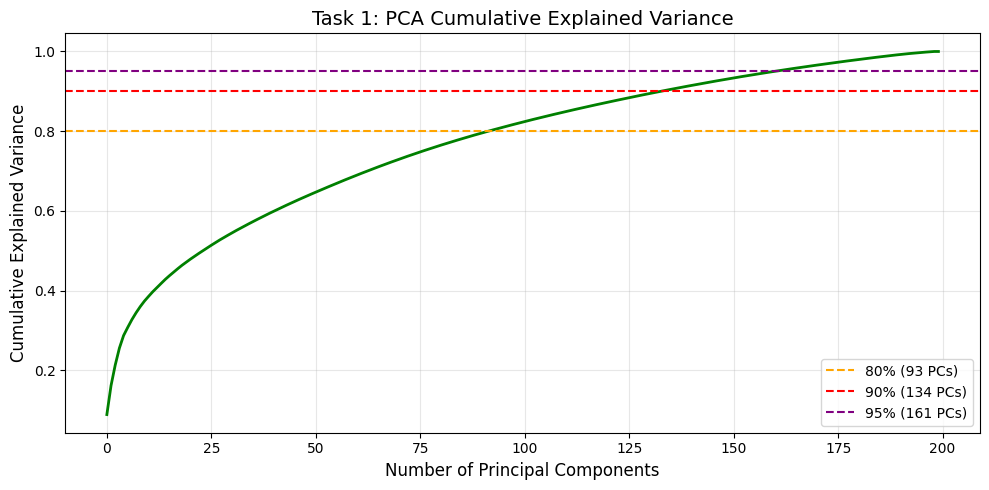

Saved: task1_cumvar.png


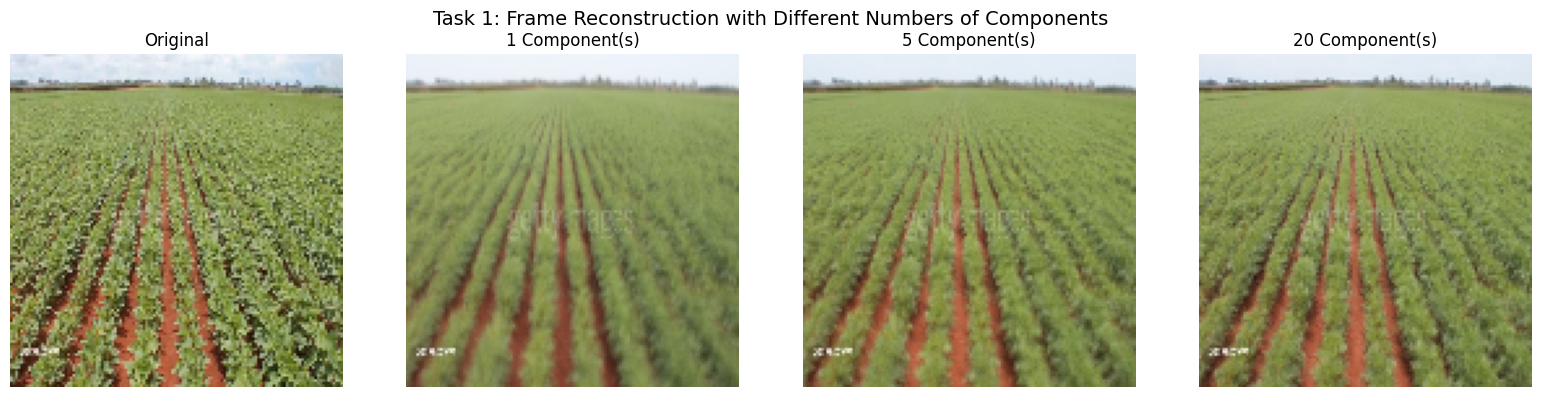

Saved: task1_reconstruction.png


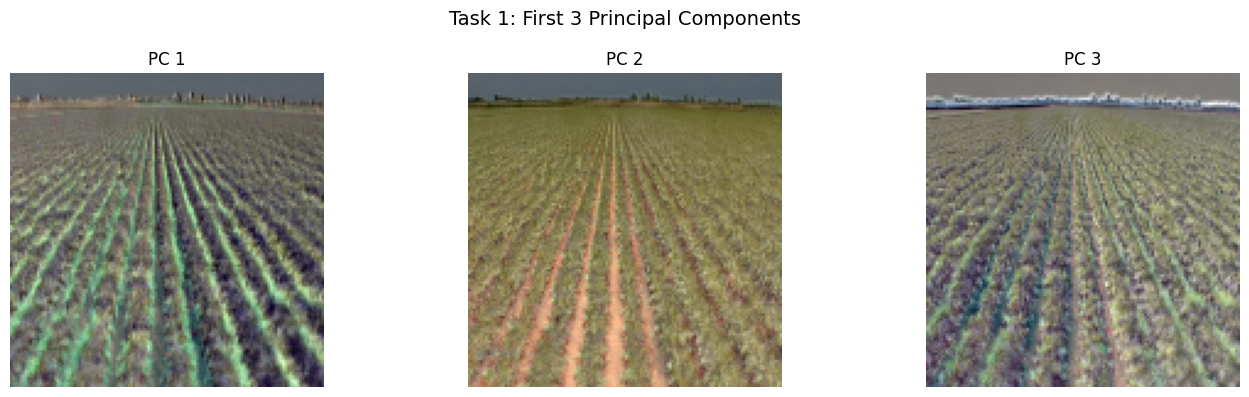

Saved: task1_components.png


In [2]:
# Task 1: Low-Rank Video Modeling (PCA on Raw Frames)

print("\n" + "="*60)
print("Task 1: Low-Rank Video Modeling with PCA")
print("="*60)

# Full PCA
pca_full = PCA()
pca_full.fit(X)

# Cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Number of components needed for 80%, 90%, 95%
n80 = np.argmax(cumvar >= 0.80) + 1
n90 = np.argmax(cumvar >= 0.90) + 1
n95 = np.argmax(cumvar >= 0.95) + 1
print(f"  80% variance -> {n80} components")
print(f"  90% variance -> {n90} components")
print(f"  95% variance -> {n95} components")

# Plot cumulative variance
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cumvar, linewidth=2, color='green')
ax.axhline(0.80, color='orange', linestyle='--', label=f'80% ({n80} PCs)')
ax.axhline(0.90, color='red',    linestyle='--', label=f'90% ({n90} PCs)')
ax.axhline(0.95, color='purple', linestyle='--', label=f'95% ({n95} PCs)')
ax.set_xlabel('Number of Principal Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax.set_title('Task 1: PCA Cumulative Explained Variance', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task1_cumvar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task1_cumvar.png")

# Reconstruct video with 1, 5, 20 components
def reconstruct_frames(X, n_components, H, W, C):
    pca = PCA(n_components=n_components)
    X_transformed = pca.fit_transform(X)
    X_reconstructed = pca.inverse_transform(X_transformed)
    X_reconstructed = np.clip(X_reconstructed, 0, 1)
    return X_reconstructed.reshape(-1, H, W, C)

sample_idx = T // 2

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(frames[sample_idx])
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

for i, n in enumerate([1, 5, 20]):
    recon = reconstruct_frames(X, n, H, W, C)
    axes[i+1].imshow(recon[sample_idx])
    axes[i+1].set_title(f'{n} Component(s)', fontsize=12)
    axes[i+1].axis('off')

fig.suptitle('Task 1: Frame Reconstruction with Different Numbers of Components', fontsize=14)
plt.tight_layout()
plt.savefig('task1_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task1_reconstruction.png")

# Visualize first 3 principal components
pca_20 = PCA(n_components=20)
pca_20.fit(X)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i in range(3):
    comp = pca_20.components_[i].reshape(H, W, C)
    comp_vis = (comp - comp.min()) / (comp.max() - comp.min())
    axes[i].imshow(comp_vis)
    axes[i].set_title(f'PC {i+1}', fontsize=12)
    axes[i].axis('off')
fig.suptitle('Task 1: First 3 Principal Components', fontsize=14)
plt.tight_layout()
plt.savefig('task1_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task1_components.png")


Task 2: Keyframe Extraction via Reconstruction Error
  Mean error:  20.5234
  Max error:   28.6654


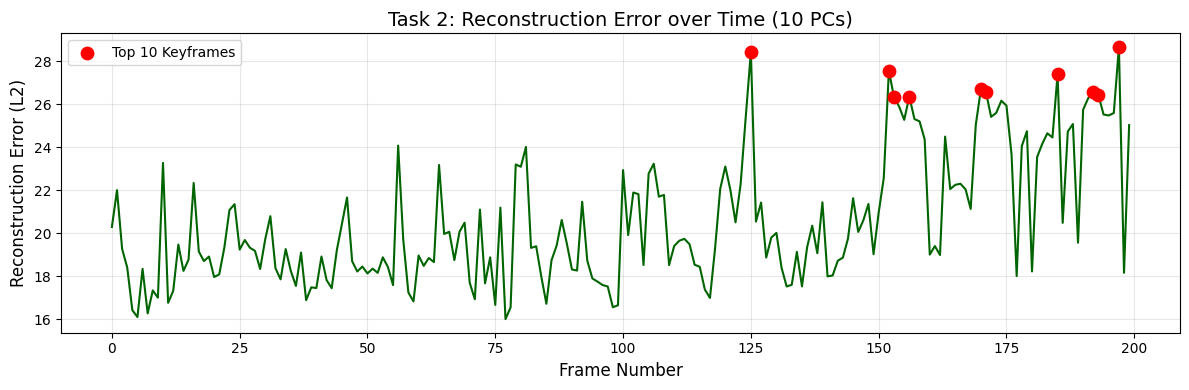

Saved: task2_error_curve.png


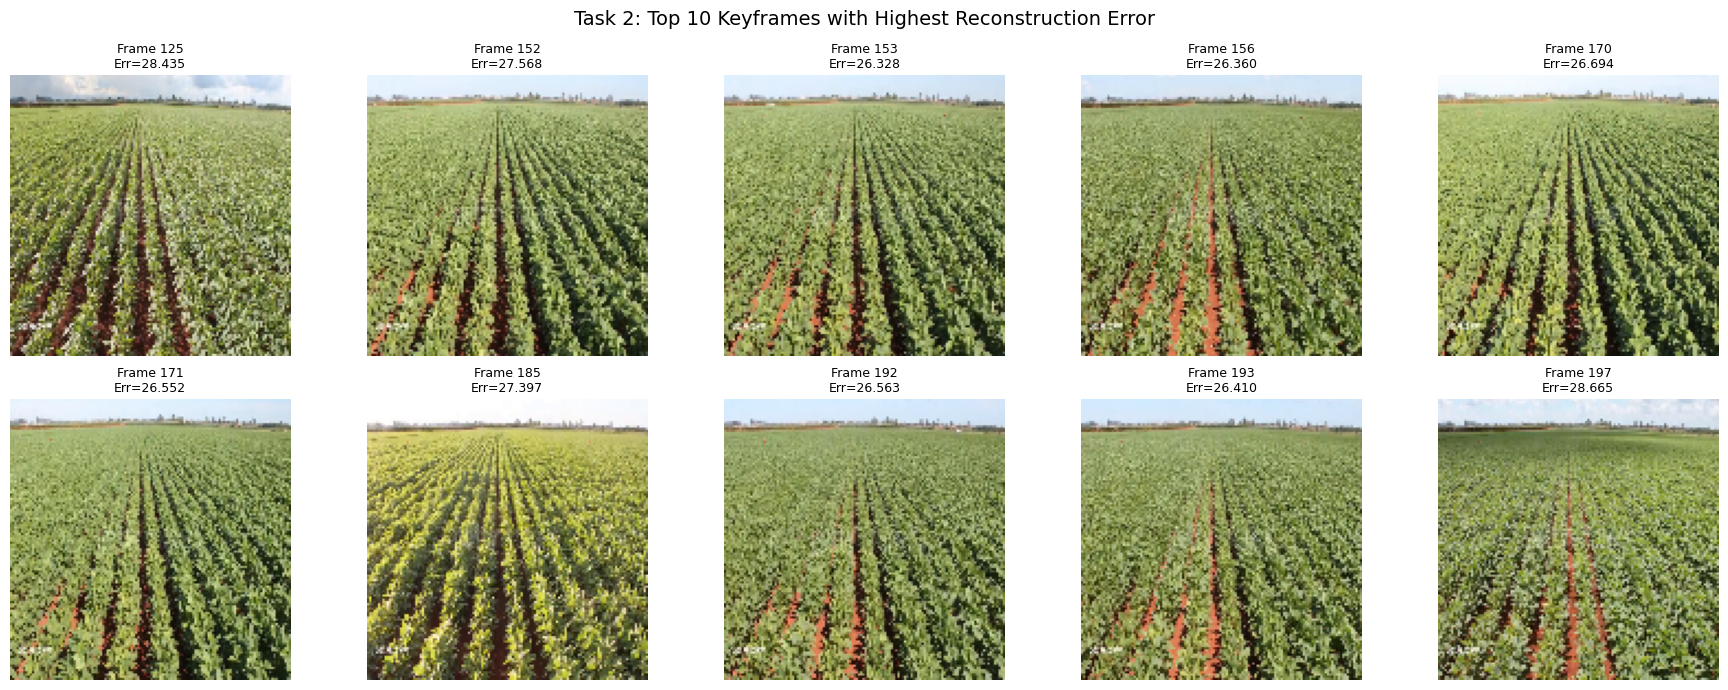

Saved: task2_keyframes.png


In [3]:
# Task 2: Keyframe Extraction via Reconstruction Error

print("\n" + "="*60)
print("Task 2: Keyframe Extraction via Reconstruction Error")
print("="*60)

n_components_task2 = 10
pca_t2 = PCA(n_components=n_components_task2)
X_proj = pca_t2.fit_transform(X)
X_recon = pca_t2.inverse_transform(X_proj)

# Per-frame reconstruction error (L2)
errors = np.linalg.norm(X - X_recon, axis=1)
print(f"  Mean error:  {errors.mean():.4f}")
print(f"  Max error:   {errors.max():.4f}")

# Top 10 frames with highest error
top10_idx = np.argsort(errors)[-10:]
top10_sorted = sorted(top10_idx)

# Plot error over time
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(errors, color='darkgreen', linewidth=1.5)
ax.scatter(top10_idx, errors[top10_idx], color='red', zorder=5,
           label='Top 10 Keyframes', s=80)
ax.set_xlabel('Frame Number', fontsize=12)
ax.set_ylabel('Reconstruction Error (L2)', fontsize=12)
ax.set_title(f'Task 2: Reconstruction Error over Time ({n_components_task2} PCs)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task2_error_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task2_error_curve.png")

# Display top 10 keyframes
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, idx in enumerate(top10_sorted):
    ax = axes[i//5][i%5]
    ax.imshow(frames[idx])
    ax.set_title(f'Frame {idx}\nErr={errors[idx]:.3f}', fontsize=9)
    ax.axis('off')
fig.suptitle('Task 2: Top 10 Keyframes with Highest Reconstruction Error', fontsize=14)
plt.tight_layout()
plt.savefig('task2_keyframes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task2_keyframes.png")